In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('breast-cancer.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [3]:
df.shape

(569, 32)

In [4]:
df.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [5]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [6]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [7]:
df.drop(columns='id',inplace=True)

In [8]:
df['diagnosis_num'] = df.diagnosis.map({'M':1, 'B':0})

In [9]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_num
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [10]:
df.reset_index(drop=True,inplace=True)

In [12]:
df.head(3)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_num
0,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1


In [14]:
patient_idx = np.arange(len(df))

In [15]:
patient_idx

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [16]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'diagnosis_num'],
      dtype='object')

In [17]:
df['diagnosis'].nunique()

2

In [19]:
df.diagnosis.unique()

array(['M', 'B'], dtype=object)

In [18]:
df['radius_mean'].nunique()

456

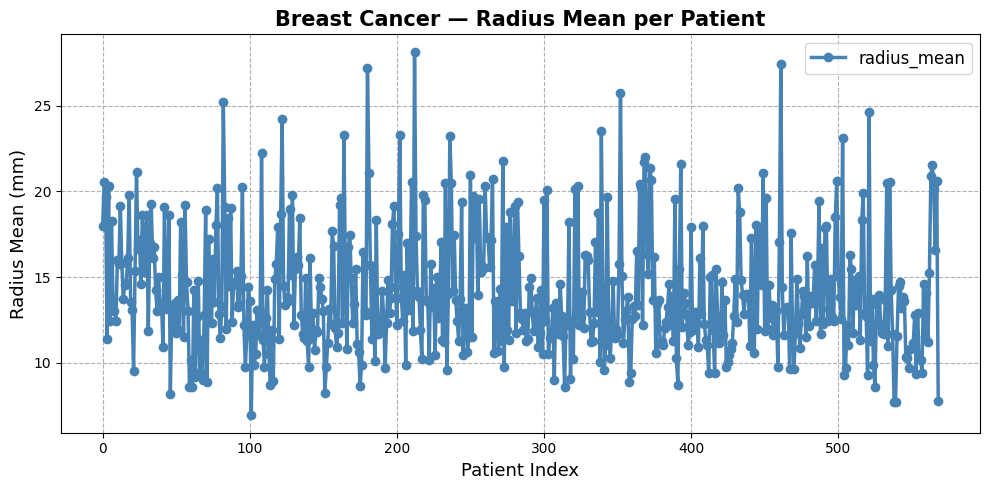

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(patient_idx, df['radius_mean'],
        color='steelblue', linewidth=2.5,
        marker='o', markersize=6, label='radius_mean')

ax.set_title('Breast Cancer — Radius Mean per Patient', fontsize=15, fontweight='bold')
ax.set_xlabel('Patient Index', fontsize=13)
ax.set_ylabel('Radius Mean (mm)', fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, alpha=1, linestyle='--')

plt.tight_layout()
plt.savefig('plot.png', dpi=150, bbox_inches='tight')
plt.show()

1

fig, ax = plt.subplots(figsize=(10, 5))

এখানে figure এবং axis তৈরি করা হচ্ছে।

plt.subplots() → একটি নতুন plotting area তৈরি করে

fig → পুরো ছবির container (পুরো canvas)

ax → সেই ছবির ভিতরের plotting area যেখানে graph আঁকা হবে

সহজভাবে ভাবলে:

Figure (fig)

   └── Axis (ax) → এখানে graph আঁকা হয়

figsize=(10,5)

মানে figure-এর size:

width = 10 inch

height = 5 inch

তাই গ্রাফটা একটু চওড়া হবে।

2
ax.plot(patient_idx, df['radius_mean'],
        color='steelblue', linewidth=2.5,
        marker='o', markersize=6, label='radius_mean')

এখানে line graph আঁকা হচ্ছে।

ax.plot(x, y)

patient_idx → x-axis data

df['radius_mean'] → y-axis data

মানে প্রতিটি patient-এর জন্য radius_mean value plot হচ্ছে।

Style parameters

color='steelblue'
লাইনটির রং steel blue।

linewidth=2.5
লাইনের পুরুত্ব।

marker='o'
প্রতিটি data point-এ একটি circle marker থাকবে।

markersize=6
circle-এর size।

label='radius_mean'
legend-এ এই লাইনের নাম কী হবে।

3

ax.set_title('Breast Cancer — Radius Mean per Patient', fontsize=15, fontweight='bold')

গ্রাফের title সেট করা হচ্ছে।

Title:

Breast Cancer — Radius Mean per Patient

Style:

fontsize=15 → font size

fontweight='bold' → bold text

4

ax.set_xlabel('Patient Index', fontsize=13)

x-axis এর label।

Patient Index

মানে x-axis এ patient number দেখাচ্ছে।

5

ax.set_ylabel('Radius Mean (mm)', fontsize=13)

y-axis এর label।

Radius Mean (mm)

মানে radius এর mean value (millimeter এ)।

6

ax.legend(fontsize=12)

Legend যোগ করা হচ্ছে।

Legend হলো graph-এর পাশে ছোট box যেখানে line-এর meaning লেখা থাকে।

এখানে দেখাবে:

radius_mean

7

ax.grid(True, alpha=0.3, linestyle='--')

Graph এর background-এ grid line যোগ করা হচ্ছে।

Parameters:

True → grid on

alpha=0.3

grid-এর transparency (0 = invisible, 1 = solid)

linestyle='--'

dashed line grid

8

plt.tight_layout()

Graph এর সব element যেন overlap না করে সেই জন্য automatic spacing adjust করে।

এটা না দিলে অনেক সময় title বা label কেটে যায়।

9

plt.savefig('plot.png', dpi=150, bbox_inches='tight')

Graph কে image file হিসেবে save করা হচ্ছে।

plot.png → file name

dpi=150

image resolution (dots per inch)

bbox_inches='tight'

extra white space কেটে দেয়।

10

plt.show()

Graph কে screen এ display করে।

Jupyter বা Python run করলে এখানেই graph দেখা যাবে।

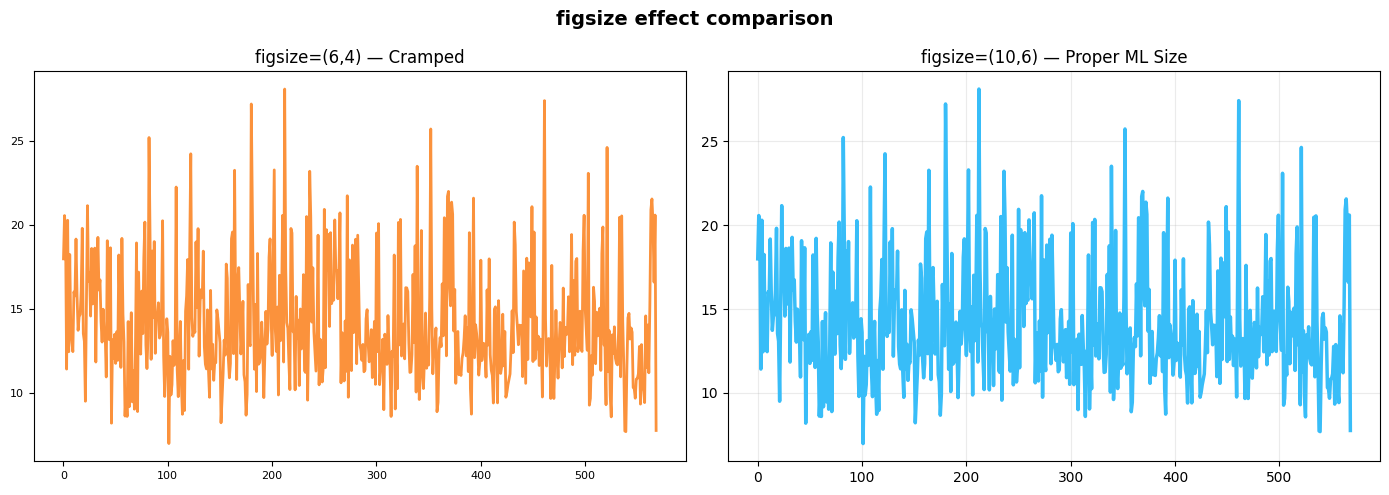

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# বাম — cramped (tick label ছোট)
axes[0].plot(patient_idx, df['radius_mean'], color='#fb923c', lw=2)
axes[0].set_title('figsize=(6,4) — Cramped')
axes[0].tick_params(labelsize=8)

# ডান — proper ML size
axes[1].plot(patient_idx, df['radius_mean'], color='#38bdf8', lw=2.5)
axes[1].set_title('figsize=(10,6) — Proper ML Size')
axes[1].grid(True, alpha=0.25)

fig.suptitle('figsize effect comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

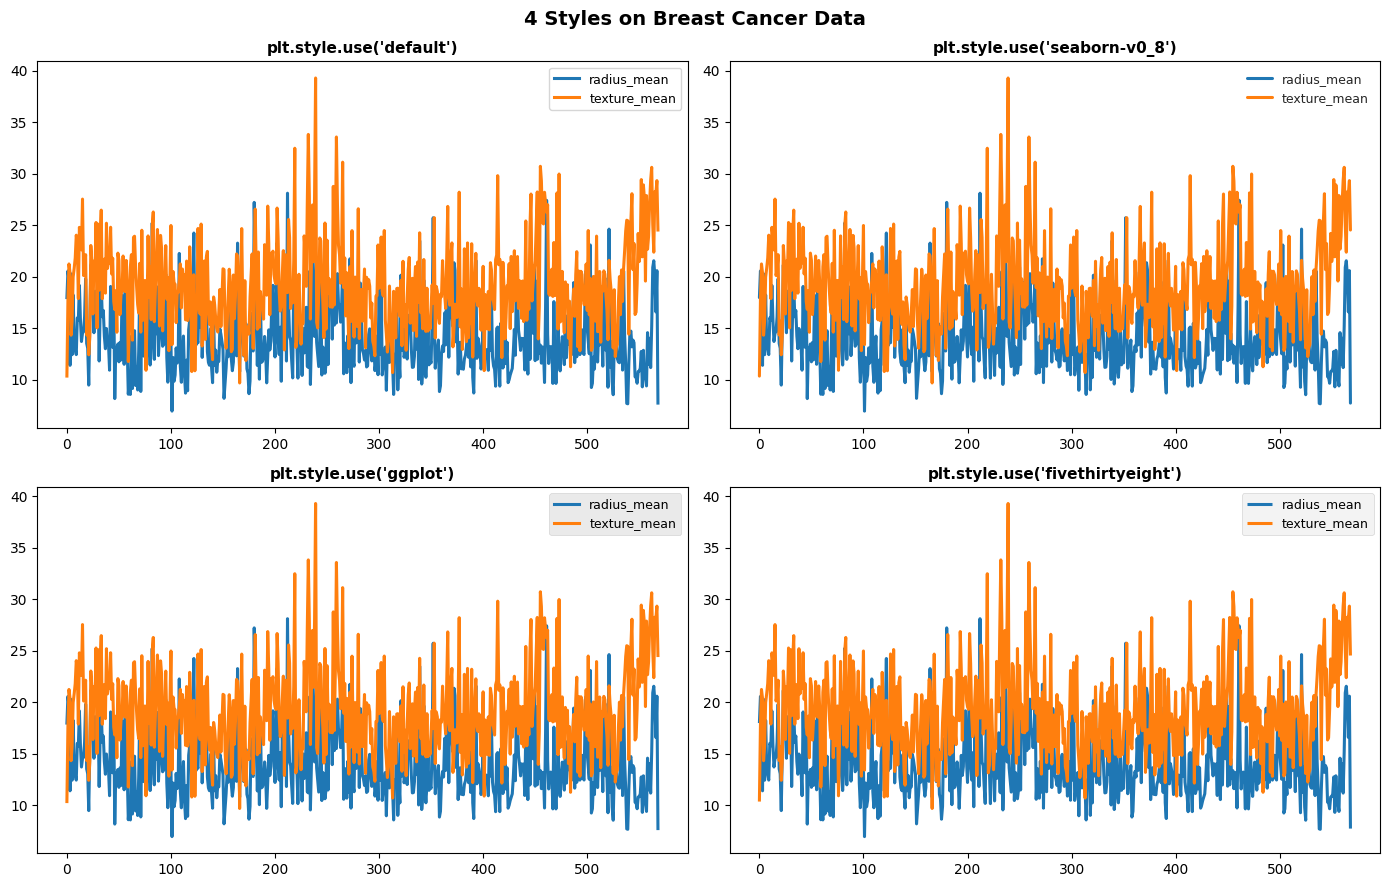

In [26]:
styles = ['default', 'seaborn-v0_8', 'ggplot', 'fivethirtyeight']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, style in zip(axes.flat, styles):
    with plt.style.context(style):       # শুধু এই block-এ style apply হয়
        ax.plot(patient_idx, df['radius_mean'],  lw=2.2, label='radius_mean')
        ax.plot(patient_idx, df['texture_mean'], lw=2.2, label='texture_mean')
        ax.set_title(f"plt.style.use('{style}')", fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)

fig.suptitle('4 Styles on Breast Cancer Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

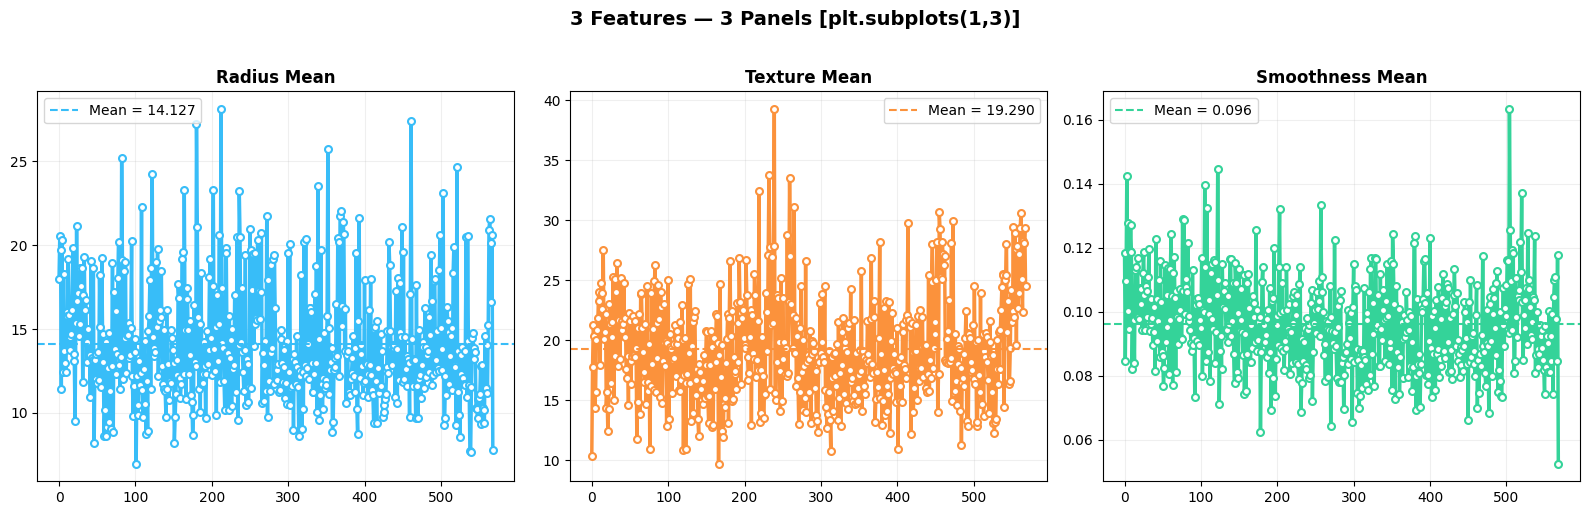

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

panel_data = [
    ('radius_mean',     '#38bdf8', 'Radius Mean (mm)'),
    ('texture_mean',    '#fb923c', 'Texture Mean'),
    ('smoothness_mean', '#34d399', 'Smoothness Mean'),
]

for ax, (col, color, ylabel) in zip(axes, panel_data):
    ax.plot(patient_idx, df[col], color=color, lw=2.5,
            marker='o', ms=5, markerfacecolor='white', markeredgewidth=1.5)
    mean_val = df[col].mean()
    ax.axhline(mean_val, color=color, linestyle='--', lw=1.5,
               label=f'Mean = {mean_val:.3f}')    # dashed mean line
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)

fig.suptitle('3 Features — 3 Panels [plt.subplots(1,3)]',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [28]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'diagnosis_num'],
      dtype='object')